---
## ✅ Task 1 – Data Collection & Dataset Understanding
**Goal:** Load the dataset and understand its structure.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── Load dataset ──────────────────────────────────────────────────────────
df = pd.read_excel('data.xlsx')  

print("Shape:", df.shape)
print()
print("Columns & Data Types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()


Shape: (1200, 14)

Columns & Data Types:
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

First 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
# Dataset size & feature summary
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()
print("Column descriptions:")
desc = {
    'OrderID'        : 'Unique order identifier',
    'Date'           : 'Date the order was placed',
    'CustomerID'     : 'Unique customer identifier',
    'Product'        : 'Product name',
    'Quantity'       : 'Number of units ordered',
    'UnitPrice'      : 'Price per unit (USD)',
    'ShippingAddress': 'Delivery address',
    'PaymentMethod'  : 'Payment method used',
    'OrderStatus'    : 'Current status of the order',
    'TrackingNumber' : 'Shipment tracking number',
    'ItemsInCart'    : 'Total items in cart at checkout',
    'CouponCode'     : 'Coupon applied (if any)',
    'ReferralSource' : 'How the customer found us',
    'TotalPrice'     : 'Final price after quantity × unit price',
}
for col, info in desc.items():
    print(f"  {col:<18}: {info}")


Rows   : 1200
Columns: 14

Column descriptions:
  OrderID           : Unique order identifier
  Date              : Date the order was placed
  CustomerID        : Unique customer identifier
  Product           : Product name
  Quantity          : Number of units ordered
  UnitPrice         : Price per unit (USD)
  ShippingAddress   : Delivery address
  PaymentMethod     : Payment method used
  OrderStatus       : Current status of the order
  TrackingNumber    : Shipment tracking number
  ItemsInCart       : Total items in cart at checkout
  CouponCode        : Coupon applied (if any)
  ReferralSource    : How the customer found us
  TotalPrice        : Final price after quantity × unit price


---
## ✅ Task 2 – Data Cleaning & Preprocessing 🧹
**Goal:** Handle missing values, duplicates, and formatting issues.


In [3]:
# ── Missing values ────────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print()

# CouponCode has 309 nulls → fill with 'No Coupon'
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

print("After cleaning – missing values:")
print(df.isnull().sum())


Missing values per column:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

After cleaning – missing values:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [4]:
# ── Duplicates ────────────────────────────────────────────────────────────
print(f"Duplicate rows before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after : {df.duplicated().sum()}")


Duplicate rows before: 0
Duplicate rows after : 0


In [5]:
# ── Formatting ────────────────────────────────────────────────────────────
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Add helper columns for time-based analysis
df['Month'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()

# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

print("Cleaning complete. Final shape:", df.shape)
df.head(3)


Cleaning complete. Final shape: (1200, 16)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,DayOfWeek
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1,January,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7,August,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.4,February,Tuesday


---
## ✅ Task 3 – Exploratory Data Analysis (EDA) 📊
**Goal:** Calculate statistics, find trends, identify outliers.


In [6]:
# ── Basic statistics ──────────────────────────────────────────────────────
print("Descriptive Statistics:")
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe().round(2)


Descriptive Statistics:


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40


In [7]:
# ── Value counts for categorical columns ─────────────────────────────────
for col in ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(5))



--- Product ---
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

--- OrderStatus ---
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

--- ReferralSource ---
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [8]:
# ── Outlier detection (IQR method) ───────────────────────────────────────
for col in ['TotalPrice', 'Quantity']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"Outliers in {col}: {len(outliers)} rows")

# ── Key findings ─────────────────────────────────────────────────────────
print("\n=== Key Findings ===")
print(f"Average order value : ${df['TotalPrice'].mean():.2f}")
print(f"Top product         : {df['Product'].value_counts().idxmax()}")
print(f"Top payment method  : {df['PaymentMethod'].value_counts().idxmax()}")
print(f"Coupon usage rate   : {(df['CouponCode'] != 'No Coupon').mean()*100:.1f}%")


Outliers in TotalPrice: 8 rows
Outliers in Quantity: 0 rows

=== Key Findings ===
Average order value : $1053.97
Top product         : Printer
Top payment method  : Online
Coupon usage rate   : 74.2%


---
## ✅ Task 4 – Data Visualization 📈
**Goal:** Create charts to communicate insights clearly.


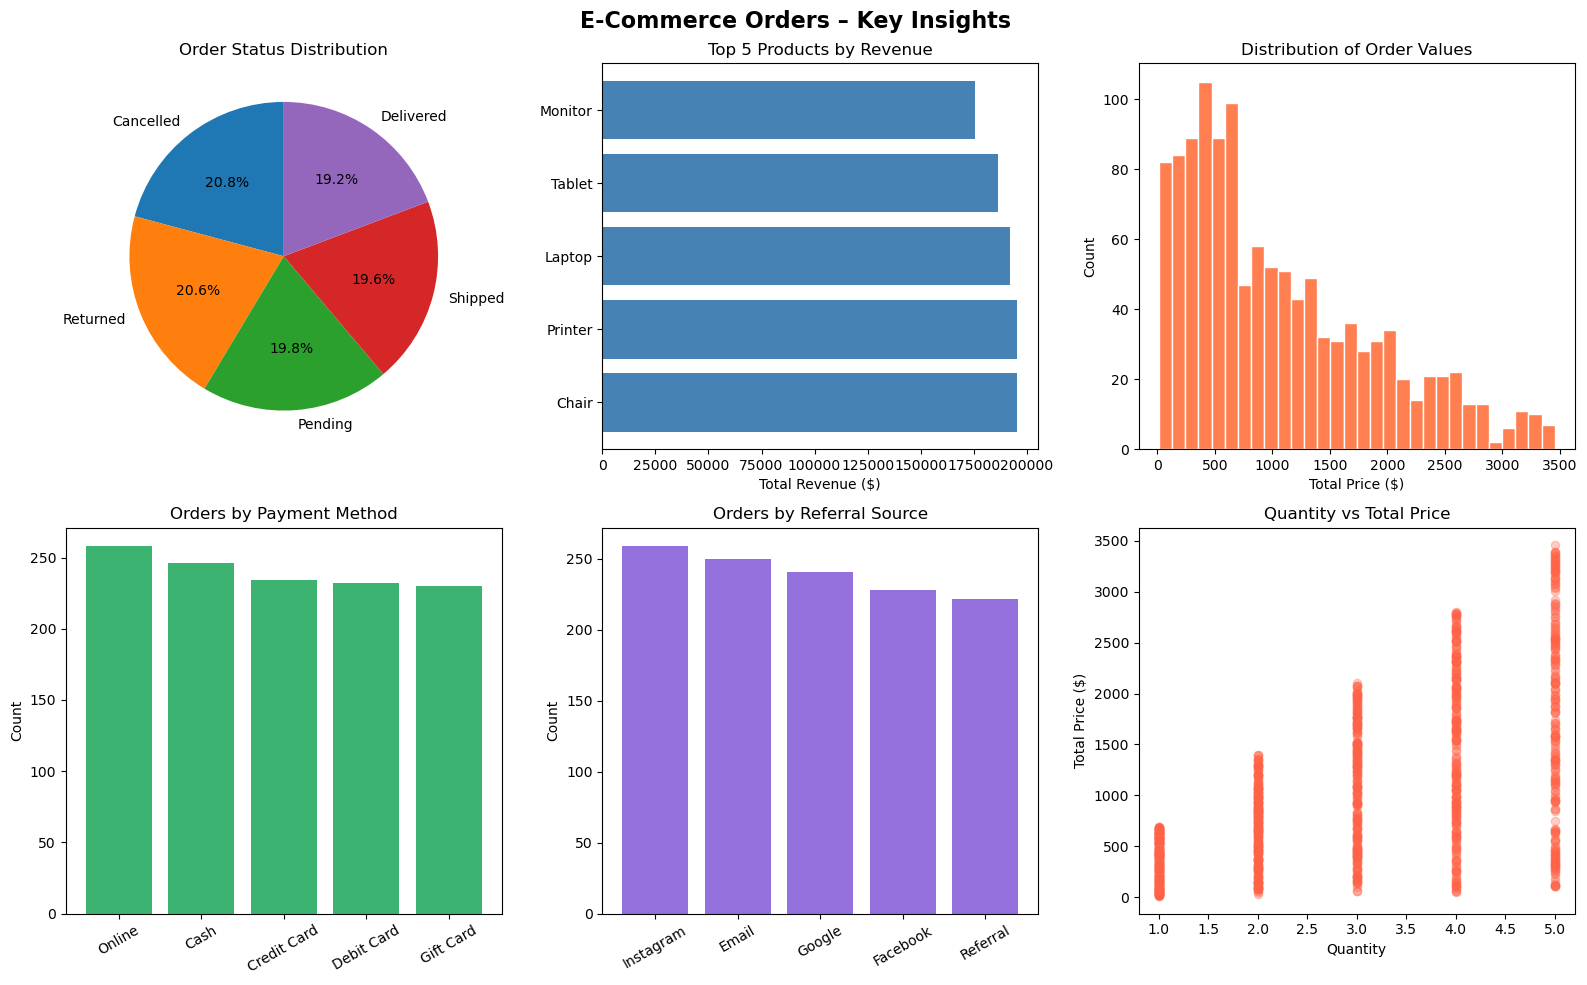

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('E-Commerce Orders – Key Insights', fontsize=16, fontweight='bold')

# 1. Order Status distribution
status_counts = df['OrderStatus'].value_counts()
axes[0,0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Order Status Distribution')

# 2. Top 5 Products by revenue
top_products = df.groupby('Product')['TotalPrice'].sum().nlargest(5)
axes[0,1].barh(top_products.index, top_products.values, color='steelblue')
axes[0,1].set_title('Top 5 Products by Revenue')
axes[0,1].set_xlabel('Total Revenue ($)')

# 3. TotalPrice distribution
axes[0,2].hist(df['TotalPrice'], bins=30, color='coral', edgecolor='white')
axes[0,2].set_title('Distribution of Order Values')
axes[0,2].set_xlabel('Total Price ($)')
axes[0,2].set_ylabel('Count')

# 4. Payment method counts
pay_counts = df['PaymentMethod'].value_counts()
axes[1,0].bar(pay_counts.index, pay_counts.values, color='mediumseagreen')
axes[1,0].set_title('Orders by Payment Method')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Referral Source
ref_counts = df['ReferralSource'].value_counts()
axes[1,1].bar(ref_counts.index, ref_counts.values, color='mediumpurple')
axes[1,1].set_title('Orders by Referral Source')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Quantity vs TotalPrice scatter
axes[1,2].scatter(df['Quantity'], df['TotalPrice'], alpha=0.3, color='tomato')
axes[1,2].set_title('Quantity vs Total Price')
axes[1,2].set_xlabel('Quantity')
axes[1,2].set_ylabel('Total Price ($)')

plt.tight_layout()
plt.show()


---
## ✅ Task 5 – Predictive Model 🚀
**Goal:** Predict `TotalPrice` using a simple Linear Regression model.


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ── Feature engineering ───────────────────────────────────────────────────
model_df = df.copy()

le = LabelEncoder()
model_df['Product_enc']       = le.fit_transform(model_df['Product'])
model_df['PaymentMethod_enc'] = le.fit_transform(model_df['PaymentMethod'])
model_df['HasCoupon']         = (model_df['CouponCode'] != 'No Coupon').astype(int)

features = ['Quantity', 'UnitPrice', 'ItemsInCart',
            'Product_enc', 'PaymentMethod_enc', 'HasCoupon']
target   = 'TotalPrice'

X = model_df[features]
y = model_df[target]

# ── Train / Test split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Train model ───────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : ${mae:.2f}")
print(f"R² Score            : {r2:.4f}")
print()
print("Feature Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:<22}: {coef:.4f}")


Mean Absolute Error : $212.09
R² Score            : 0.8909

Feature Coefficients:
  Quantity              : 350.7875
  UnitPrice             : 2.9305
  ItemsInCart           : -1.7317
  Product_enc           : 4.6372
  PaymentMethod_enc     : -2.2222
  HasCoupon             : 7.8622


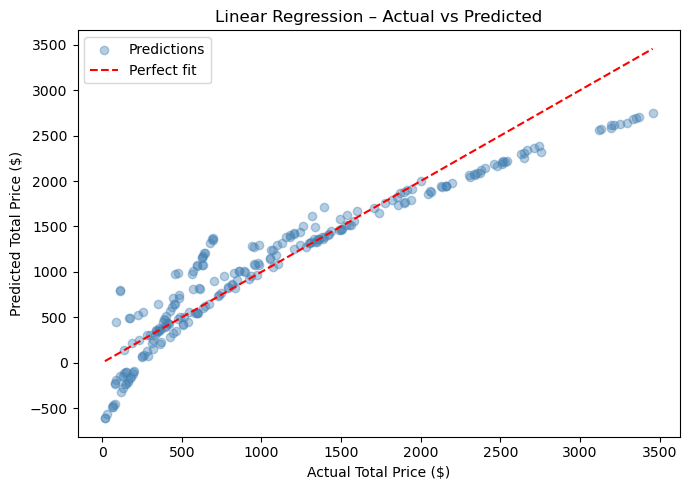


Model Summary: R² = 89.09% of variance explained.
Mean Squared Error (MSE) : $82971.33 (squared)
Root Mean Squared Error (RMSE): $288.05 (average prediction error)


In [15]:
# ── Actual vs Predicted plot ──────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
plt.xlabel('Actual Total Price ($)')
plt.ylabel('Predicted Total Price ($)')
plt.title('Linear Regression – Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"\nModel Summary: R² = {r2:.2%} of variance explained.")
print(f"Mean Squared Error (MSE) : ${mse:.2f} (squared)")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f} (average prediction error)")